In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

from probjax.nn import MLP, GaussianFourierEmbedding
from probjax.nn.nets.denoising_diffusion_model import EDM, VE, VP
from probjax.nn.nets.score_matching_model import EDMScoreMatcher

from probjax.nn.utils import ot_copula


In [3]:
d = 1
sigma = 0.01
loc = 0.1

In [4]:
def generate_data(key):
    # Mixture of Gaussians
    key, subkey = jax.random.split(key)
    u = jax.random.uniform(subkey)
    eps = jax.random.normal(key, (2,d)) * sigma
    x = jnp.where(u < 0.5, eps[0]-loc, eps[1]+loc)
    return x

def target_potential(x):
    # For a mixture of Gaussians, the potential is -log p(x)
    # So we need to negate the log probability
    logpdf1 = jax.scipy.stats.norm.logpdf(x, -loc, sigma).sum(axis=-1)
    logpdf2 = jax.scipy.stats.norm.logpdf(x, loc, sigma).sum(axis=-1)
    return jax.scipy.special.logsumexp(jnp.stack([logpdf1, logpdf2], axis=-1), axis=-1)

[0.101]


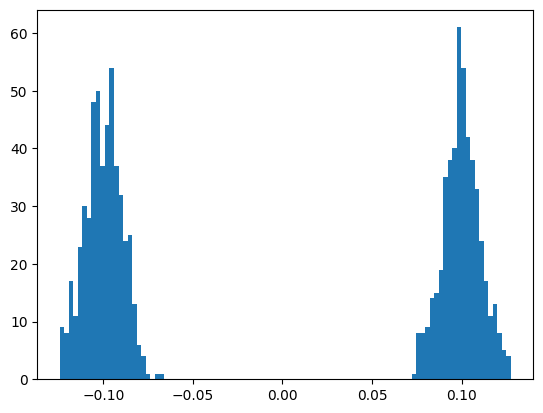

In [5]:
xs = jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(2), 1000))
print(xs.std(0))
_ = plt.hist(xs.flatten(), bins=100)

In [323]:

class BaseModel(nnx.Module):
    def __init__(self, d, rngs) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,32, rngs=rngs)
        #self.time_embedding = lambda t: jnp.repeat(t, 5, axis=-1)
        self.mlp = MLP([2*32,500,500,500,500,500,d], rngs=rngs)

    def __call__(self, t,x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        x = jnp.repeat(x, 32, axis=-1)
        inp = jnp.concatenate([time_embed, x], axis=-1)
        output = self.mlp(inp)
        return output

net = BaseModel(d, nnx.Rngs(0))
model = EDM(net, std0=1., loss_type="v")
params = nnx.state(model, nnx.Param)

In [334]:

import optax

opt = optax.chain(optax.adaptive_grad_clip(100.), optax.adam(1e-3))
opt_state = opt.init(params)

def loss_fn(params, rng, x):
    nnx.update(model, params)
    # Addition target score matching loss
    target_score_fn = jax.grad(target_potential)
    rng1, rng2 = jax.random.split(rng)
    ts = jax.random.uniform(rng1, (x.shape[0],1))*0.05 + 0.0001
    x_noisy = x + jax.random.normal(rng2, x.shape)*ts
    score_noisy = model.score(ts, x_noisy)
    target_score = jax.vmap(target_score_fn)(x)
    target_score_norm = jnp.linalg.norm(target_score, axis=-1, keepdims=True).mean()
    weight = model.weight_fn(ts) * ts**4
    #weight = (1/target_score_norm) * ts**2
    loss2 = jnp.mean((score_noisy - target_score)**2 * weight)
    #jax.debug.print("{loss2}", loss2=loss2)
    return model.loss(rng, x) + loss2

@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng,x)
    updates, opt_state = opt.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [335]:
key = jax.random.key(0)

In [336]:
opt_state = opt.init(params)

In [337]:
data_gen = jax.jit(jax.vmap(generate_data))

In [356]:
losses = []
for i in range(10):
    l = 0.
    for j in range(200):
        key,key_data, key_loss = jax.random.split(key, 3)
        xs = data_gen(jax.random.split(key_data, 10_000))
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    print(l/200)
    losses.append(l/200)

7.8953304
7.89861
7.906059
7.8871646
7.9149323
7.9033318
7.894841
7.894085
7.907216
7.898344


In [357]:
nnx.update(model, params)

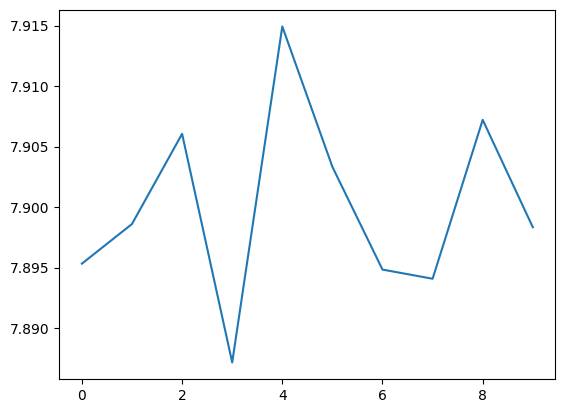

In [358]:
plt.plot(losses)

In [359]:
target_score_fn = jax.grad(target_potential)

In [360]:
xs = data_gen(jax.random.split(key_data, 10_000))

In [365]:
jnp.mean((model.score(jnp.ones((xs.shape[0],1))*0.01, xs) - jax.vmap(target_score_fn)(xs))**2)

Array(2591.704, dtype=float32)

In [362]:
eps = jax.random.normal(jax.random.PRNGKey(0), (1,))
t = 0.001
x_clean = jnp.ones((1,))*0.11
x_noise = x_clean + eps * t

score_est = model.score(jnp.array([t]), x_noise)
eps_est = model.epsilon(jnp.array([t]), x_noise)
v_est = model.v(jnp.array([t]), x_noise)

x_denoised = model.denoise(jnp.array([t]), x_noise)

In [363]:
eps_est

Array([0.031], dtype=float32)

In [349]:
v_est

Array([0.064], dtype=float32)

In [350]:
x_denoised, x_clean

(Array([0.112], dtype=float32), Array([0.11], dtype=float32))

In [351]:
x_noise

Array([0.112], dtype=float32)

In [352]:
eps

Array([1.623], dtype=float32)

In [353]:
score_est

Array([-63.628], dtype=float32)

In [354]:
target_score_fn(x_clean)

Array([-100.], dtype=float32)

In [366]:
from probjax.utils.odeint import odeint


def sample(rng):
    eps = jax.random.normal(rng, (d,)) * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(100)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x)
        return (f -0.5*g**2*score).reshape(x.shape)

    return odeint(drift, eps,ts, method="heun")


In [367]:
keys = jax.random.split(key, (10_000,))
xs = jax.vmap(sample)(keys)

(-10.0, 10.0)

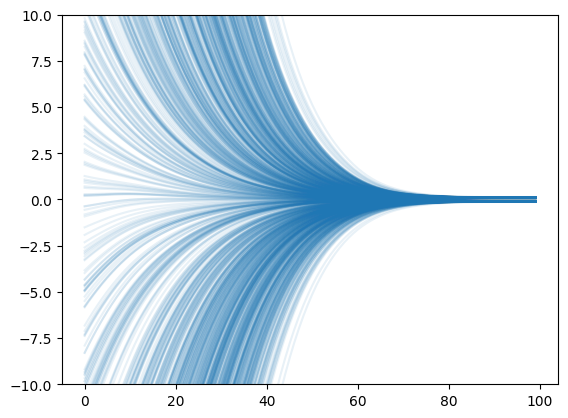

In [368]:
_ = plt.plot(xs[::10,:,0].T, color="C0", alpha=0.1)
plt.ylim(-10,10)

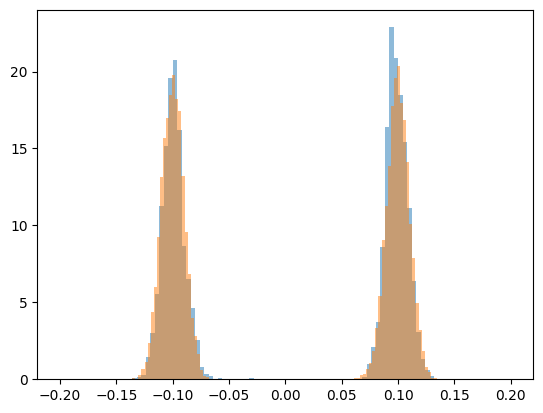

In [369]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, range=(-0.2,0.2), alpha=0.5)
_ = plt.hist(jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 10000)).flatten(), bins=100, density=True, alpha=0.5)


In [18]:
from probjax.utils.sdeint import sdeint


def sample(rng):
    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (d,))  * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(50)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t,x)
        score = model.score(t,x)

        drift_backward = f - g**2 * score
        return drift_backward

    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        g = model.diffusion(t,x)
        return g

    return sdeint(rng_sample,drift, diffusion, eps, ts, method="euler_maruyama")


In [19]:
keys = jax.random.split(key, (10_000,))

In [20]:
xs = jax.vmap(sample)(keys)

(-10.0, 10.0)

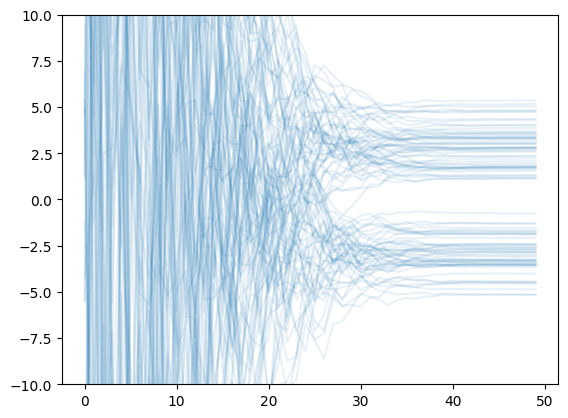

In [21]:
_ = plt.plot(xs[::100,:,0].T, color="C0", alpha=0.1)
plt.ylim(-10,10)

(-7.0, 7.0)

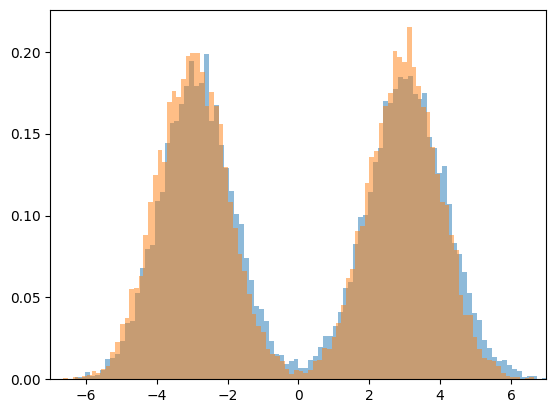

In [22]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, range=(-7,7), alpha=0.5)
_ = plt.hist(jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 10000)).flatten(), bins=100, density=True, alpha=0.5)

plt.xlim(-7,7)

In [56]:
def sample_and_logprob(rng):
    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (d,))  * model.marginal_std(model.max_noise)
    ts = jnp.linspace(0.001, 80-0.001, 1000)
    x = eps
    logq = jnp.array(0)#jax.scipy.stats.norm.logpdf(eps, 0, 80.).sum()
    dtau = ts[1]-ts[0]
    for tau in ts:

        key, rng = jax.random.split(rng)
        t = model.max_noise - tau
        print(t)
        u = model.score(t, x)
        dx_tau = (-model.drift(t, x) + model.diffusion(t,x)**2*u)*dtau + model.diffusion(t,x) * jax.random.normal(key, x.shape) * jnp.sqrt(dtau)
        dlogq = jnp.sum(dx_tau * u) + jnp.sum((-model.diffusion(t,x)**2/2 * u)* u)* dtau

        x = x + dx_tau
        logq = logq + dlogq


    return x, logq

In [57]:
model.drift(jnp.array([0.01]), jnp.array([0.,0.]))

Array([0., 0.], dtype=float32)

In [58]:
xs, log_ps = jax.vmap(sample_and_logprob)(jax.random.split(key, 10_000))

79.999
79.91892
79.838844
79.758766
79.67869
79.59861
79.51853
79.43845
79.358376
79.2783
79.19822
79.11814
79.03806
78.957985
78.87791
78.79783
78.71775
78.63767
78.557594
78.477516
78.39744
78.31736
78.23728
78.1572
78.077126
77.99705
77.91697
77.83689
77.75681
77.676735
77.59666
77.51658
77.4365
77.35642
77.276344
77.196266
77.11619
77.03611
76.95603
76.87595
76.795876
76.7158
76.63572
76.55564
76.47556
76.395485
76.31541
76.23533
76.15525
76.07517
75.995094
75.915016
75.83494
75.75486
75.67478
75.5947
75.514626
75.43455
75.35447
75.27439
75.19431
75.114235
75.03416
74.95408
74.874
74.79392
74.713844
74.633766
74.55369
74.47361
74.39353
74.31345
74.233376
74.1533
74.07322
73.99314
73.91306
73.832985
73.75291
73.67283
73.59275
73.51267
73.432594
73.352516
73.27244
73.19236
73.11228
73.0322
72.95213
72.872055
72.79198
72.7119
72.63182
72.55174
72.471664
72.39159
72.31151
72.23143
72.15135
72.07127
71.991196
71.91112
71.83104
71.75096
71.67088
71.590805
71.51073
71.43065
71.35057
71.27

In [59]:
log_ps

Array([286.578, 263.048, 227.31 , ..., 316.136, 349.497, 281.991],      dtype=float32)

In [60]:
jnp.exp(log_ps)

Array([inf, inf, inf, ..., inf, inf, inf], dtype=float32)

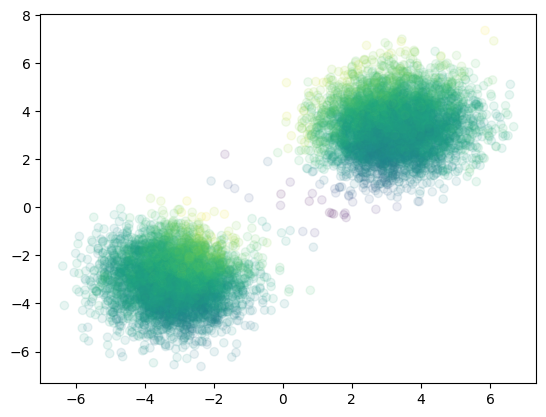

In [61]:
plt.scatter(xs[:,0], xs[:,1],c=log_ps, alpha=0.1)

In [129]:
log_ps

Array([[-17658.756],
       [ -2202.424],
       [  -741.909],
       ...,
       [ -3854.976],
       [-26769.666],
       [  -546.196]], dtype=float32)